# <font color='yellow'>**Customer Churn Prediction Model**</font>

# LIBRARIES USED

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import shap
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

 DATASET LOADING

In [6]:
df=pd.read_csv("/content/telco_churn.csv")


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Basic **EDA**

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.shape

(7043, 21)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Class Distribution of Churn

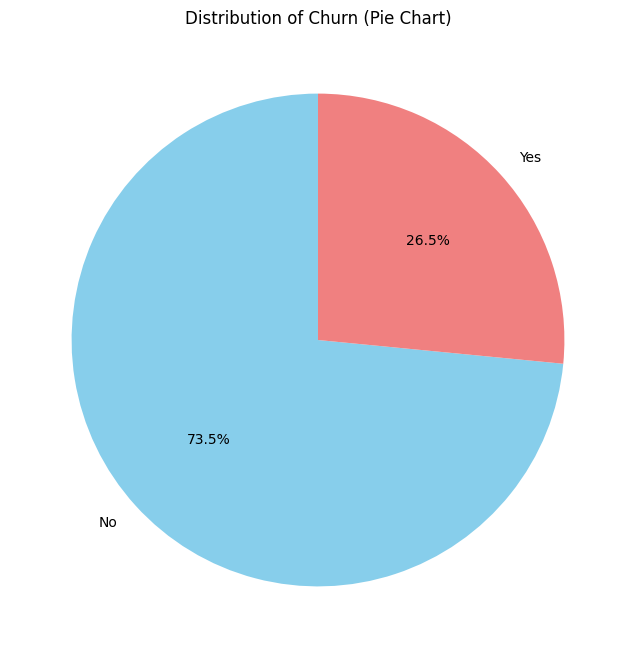

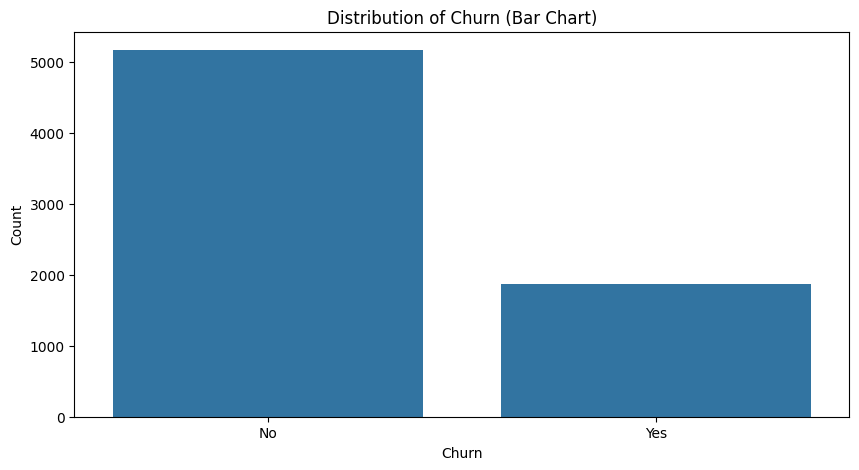

In [10]:
plt.figure(figsize=(8, 8))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Churn (Pie Chart)')
plt.ylabel('')
plt.show()
plt.figure(figsize=(10, 5))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn (Bar Chart)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

## **Removing Null Values**

In [11]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

In [13]:
imputer = KNNImputer(n_neighbors=5)
df['TotalCharges'] = imputer.fit_transform(df[['TotalCharges']])
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
##KNN IMPUTATION APPLIED AND NULL VALUES ARE REMOVED

#LABEL ENCODING

In [15]:
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

In [16]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


## **CORRELATIONAL ANALYSIS**

In [17]:
df.corr()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,1.000000,0.006288,-0.002074,-0.026729,-0.012823,0.008035,-0.006483,0.004316,-0.012407,0.013292,...,-0.006918,0.001140,-0.007777,-0.016746,0.015028,-0.001945,0.011604,-0.003916,-0.000515,-0.017447
gender,0.006288,1.000000,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.006739,-0.000863,-0.015017,...,0.000549,-0.006825,-0.006421,-0.008743,0.000126,-0.011754,0.017352,-0.014569,0.001015,-0.008612
SeniorCitizen,-0.002074,-0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,0.146185,-0.032310,-0.128221,...,-0.021398,-0.151268,0.030776,0.047266,-0.142554,0.156530,-0.038551,0.220173,0.101463,0.150889
Partner,-0.026729,-0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,0.142410,0.000891,0.150828,...,0.166330,0.126733,0.137341,0.129574,0.294806,-0.014877,-0.154798,0.096848,0.315403,-0.150448
Dependents,-0.012823,0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.024991,0.044590,0.152166,...,0.080537,0.133524,0.046885,0.021321,0.243187,-0.111377,-0.040292,-0.113890,0.063193,-0.164221
tenure,0.008035,0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.343032,-0.030359,0.325468,...,0.371105,0.322942,0.289373,0.296866,0.671607,0.006152,-0.370436,0.247900,0.817931,-0.352229
PhoneService,-0.006483,-0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,-0.020538,0.387436,-0.015198,...,0.003727,-0.019158,0.055353,0.043870,0.002247,0.016505,-0.004184,0.247398,0.112947,0.011942
MultipleLines,0.004316,-0.006739,0.146185,0.142410,-0.024991,0.343032,-0.020538,1.000000,-0.109216,0.007141,...,0.122318,0.011466,0.175059,0.180957,0.110842,0.165146,-0.176793,0.433576,0.449045,0.038037
InternetService,-0.012407,-0.000863,-0.032310,0.000891,0.044590,-0.030359,0.387436,-0.109216,1.000000,-0.028416,...,0.044944,-0.026047,0.107417,0.098350,0.099721,-0.138625,0.086140,-0.323260,-0.171487,-0.047291
OnlineSecurity,0.013292,-0.015017,-0.128221,0.150828,0.152166,0.325468,-0.015198,0.007141,-0.028416,1.000000,...,0.175985,0.285028,0.044669,0.055954,0.374416,-0.157641,-0.096726,-0.053878,0.251856,-0.289309


<Axes: >

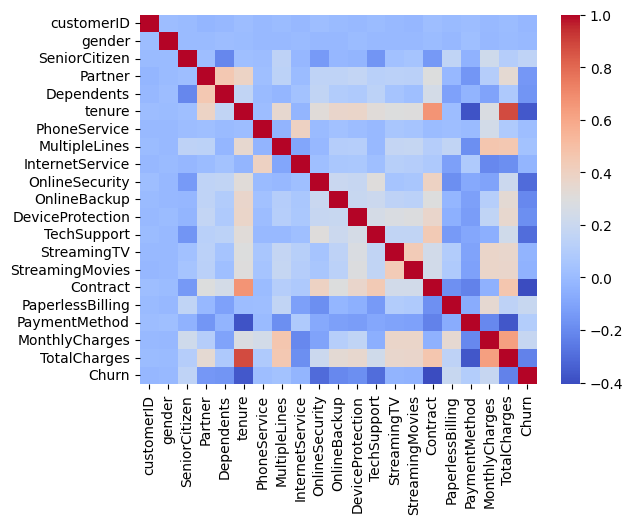

In [38]:
sns.heatmap(df.corr(method='spearman'),annot=False,cmap='coolwarm')

<Axes: xlabel='TotalCharges', ylabel='tenure'>

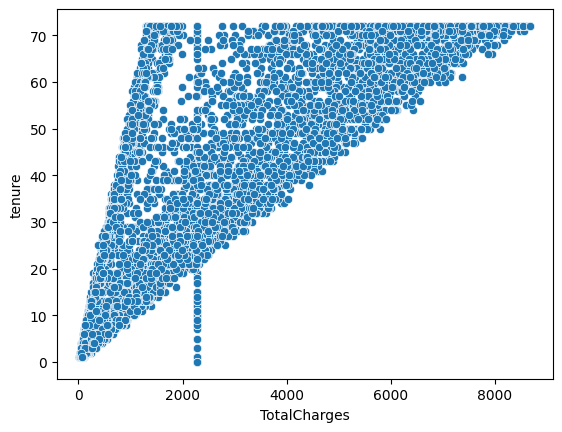

In [18]:
sns.scatterplot(x='TotalCharges',y='tenure',data=df)

### FEATURE **SCALING**

In [19]:
scaler = StandardScaler()

X = df.drop("Churn", axis=1)
y = df["Churn"]

X = scaler.fit_transform(X)

TRAIN TEST SPLIT

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **THE MODEL TRAINING PART**

LOGISTIC REGRESSION

In [25]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

RANDOM FOREST

In [26]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

SUPPORT VECTOR MACHINE SVM

In [27]:
svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

KNN CLASSIFIER

In [28]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)

### XG-Boost

In [29]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

### **Hyperparameter Tuning for XGBoost**

Let's use `GridSearchCV` to find the optimal hyperparameters for our XGBoost model.

In [30]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of boosting rounds
    'learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage to prevent overfitting
    'max_depth': [3, 5, 7], # Maximum depth of a tree
    'subsample': [0.7, 0.9, 1.0], # Subsample ratio of the training instance
    'colsample_bytree': [0.7, 0.9, 1.0] # Subsample ratio of columns when constructing each tree
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=XGBClassifier(random_state=42), # Use XGBoost classifier
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=3,
                           verbose=1, # Show progress
                           n_jobs=-1) # Use all available cores

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-validation Accuracy: {grid_search.best_score_:.4f}")

# Get the best estimator
best_xgb = grid_search.best_estimator_

# Make predictions with the best estimator
pred_best_xgb = best_xgb.predict(X_test)

# Evaluate the best model on the test set
best_xgb_accuracy = accuracy_score(y_test, pred_best_xgb)


Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Best Cross-validation Accuracy: 0.8024


## **MODEL EVALUATION**

## CLASSIFICATION REPORTS

In [31]:
print("CLASSIFICATION REPORT:XGB")
print(classification_report(y_test, pred_best_xgb))


CLASSIFICATION REPORT:XGB
              precision    recall  f1-score   support

           0       0.83      0.93      0.87      1036
           1       0.70      0.46      0.56       373

    accuracy                           0.80      1409
   macro avg       0.76      0.69      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [32]:
print(f"XGBoost Accuracy: {accuracy_score(y_test, pred_best_xgb):.4f}")

XGBoost Accuracy: 0.8048


In [33]:
print("CLASSIFICATION REPORT:SVM")
print(classification_report(y_test, pred_svm))

CLASSIFICATION REPORT:SVM
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.68      0.49      0.57       373

    accuracy                           0.80      1409
   macro avg       0.76      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [34]:
print("CLASSIFICATION REPORT:KNN")
print(classification_report(y_test, pred_knn))

CLASSIFICATION REPORT:KNN
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1036
           1       0.56      0.50      0.53       373

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.69      1409
weighted avg       0.76      0.76      0.76      1409



In [35]:
print("CLASSIFICATION REPORT:RANDOM FOREST")
print(classification_report(y_test, pred_rf))

CLASSIFICATION REPORT:RANDOM FOREST
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.49      0.56       373

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [36]:
print("CLASSIFICATION REPORT:LOGISTIC REGRESSION")
print(classification_report(y_test, pred_lr))


CLASSIFICATION REPORT:LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



## Accuracy SCORE

In [37]:
accuracy_xgb=accuracy_score(y_test, pred_xgb)

In [38]:
acuracy_svm=accuracy_score(y_test, pred_svm)

In [39]:
accuracy_knn=accuracy_score(y_test,pred_knn)

In [40]:
accuracy_lr=accuracy_score(y_test,pred_lr)

In [41]:
accuracy_rf=accuracy_score(y_test,pred_rf)

# Confusion Matrix

In [42]:
print("XGBOOST")
print(confusion_matrix(y_test, pred_xgb))


XGBOOST
[[913 123]
 [172 201]]


In [43]:
print("SVM")
print(confusion_matrix(y_test, pred_svm))

SVM
[[950  86]
 [190 183]]


In [44]:
print("KNN")
print(confusion_matrix(y_test, pred_knn))

KNN
[[891 145]
 [187 186]]


In [45]:
print("LogisticRegression")
print(confusion_matrix(y_test, pred_lr))

LogisticRegression
[[933 103]
 [156 217]]


### **MODEL COMPARISON**

In [46]:
results = pd.DataFrame({
    "Model": ["XGBoost","Logistic Regression", "Random Forest", "SVM", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, pred_best_xgb),
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_svm),
        accuracy_score(y_test, pred_knn)

    ],
    "Confusion Matrix": [
        confusion_matrix(y_test, pred_best_xgb),
        confusion_matrix(y_test, pred_lr),
        confusion_matrix(y_test, pred_rf),
        confusion_matrix(y_test, pred_svm),
        confusion_matrix(y_test, pred_knn)

    ]
})
results



,Model,Accuracy,Confusion Matrix
0,XGBoost,0.804826,"[[962, 74], [201, 172]]"
1,Logistic Regression,0.816182,"[[933, 103], [156, 217]]"
2,Random Forest,0.799148,"[[943, 93], [190, 183]]"
3,SVM,0.804116,"[[950, 86], [190, 183]]"
4,KNN,0.764372,"[[891, 145], [187, 186]]"


In [47]:
results.to_csv("results.csv")



FINAL PREDICTION RESULT

In [48]:
predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": pred_xgb
})

predictions.head(10)

,Actual,Predicted
185,1,0
2715,0,0
3825,0,0
1807,1,1
132,0,0
1263,1,0
3732,0,0
1672,0,0
811,1,0
2526,1,0


NEW CUSTOMER CHURN PREDICTION

In [49]:
sample_customer = X_test[0].reshape(1, -1)

prediction = xgb.predict(sample_customer)

print("Prediction:", prediction)

Prediction: [0]


## **FEATURE IMPORTANCE**

In [50]:
importance = xgb.feature_importances_

In [54]:
feature_importance = pd.DataFrame({
    "Feature": df.drop("Churn", axis=1).columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
15,Contract,0.406709
8,InternetService,0.108590
9,OnlineSecurity,0.070880
12,TechSupport,0.055412
5,tenure,0.031783
6,PhoneService,0.029926
14,StreamingMovies,0.028739
16,PaperlessBilling,0.025799
18,MonthlyCharges,0.023979
2,SeniorCitizen,0.023878


FEATURE IMPORTANCE IN XGBOOST

/tmp/ipykernel_9872/2033809822.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')


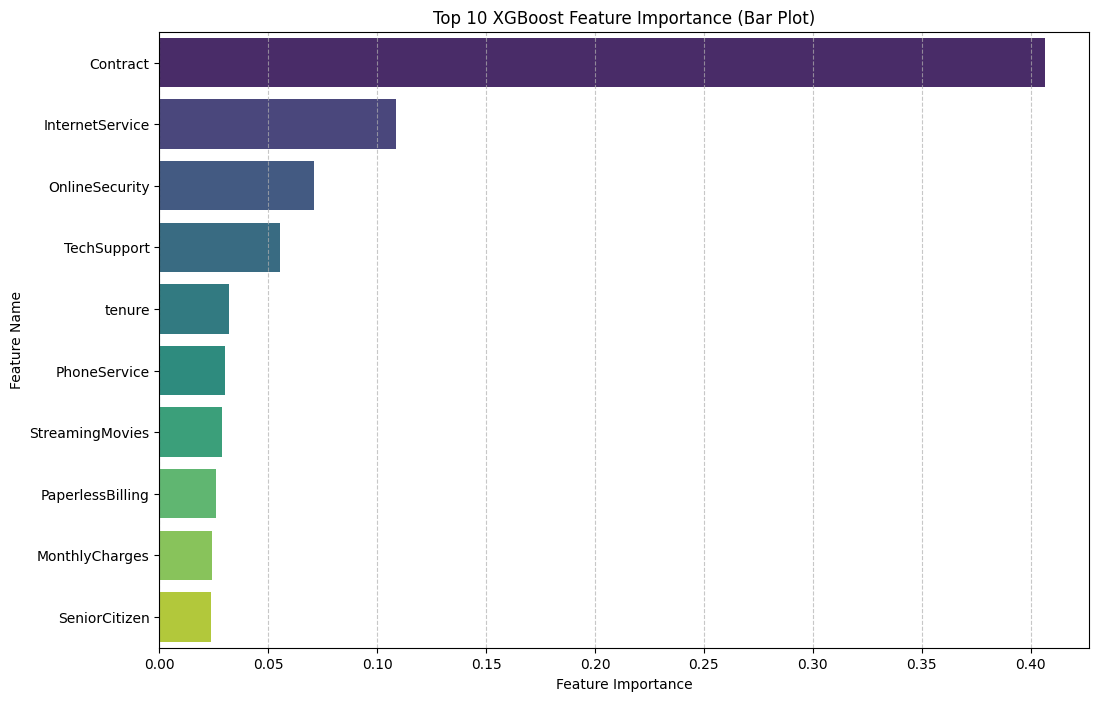

In [53]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 XGBoost Feature Importance (Bar Plot)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# **CONCLUSION**

In this project, a machine learning model was developed to predict customer churn using the telecom customer dataset. The data was preprocessed by handling missing values, encoding categorical variables, and applying feature scaling. Multiple models including Logistic Regression, Random Forest, SVM, KNN, and XGBoost were trained and compared. Among these, XGBoost, Random Forest and Logistic Regression achieved the highest accuracy and performed the best for churn prediction. Feature importance analysis indicated that factors such as contract type, monthly charges, tenure, and total charges play a significant role in customer churn. The model can help companies identify customers who are likely to churn and take actions to improve customer retention.